In [2]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from itables import init_notebook_mode, show

# Eigene robusten Parquet-Helper
from utils.parquet_io import load_parquet

init_notebook_mode(all_interactive=True)
# Projekt-Root bestimmen (2 Ebenen über notebooks/)
ROOT = Path.cwd().parents[0]   # oder ggf. .parents[1], je nachdem wo dein notebooks/ liegt
DATA_DIR = ROOT / "data"

print("ROOT:", ROOT)
print("DATA_DIR:", DATA_DIR)
def load_and_info(path: Path) -> pd.DataFrame:
    """Lädt ein Parquet und gibt Infos aus."""
    df = load_parquet(path)
    print(f"\n--- {path.name} ---")
    print(f"Shape: {df.shape}")
    print(f"Columns: {len(df.columns)}")
    return df

ROOT: C:\Dev\Bachelorarbeit
DATA_DIR: C:\Dev\Bachelorarbeit\data


In [1]:
raw_dir = DATA_DIR / "raw" / "assets_regions"

df_btc = load_and_info(raw_dir / "SPY.parquet")
display(df_btc.head(1200), df_btc.tail())

df_spy = load_and_info(raw_dir / "ACWI.parquet")
display(df_spy.head(1200), df_spy.tail())


raw_dir = DATA_DIR / "raw"

rf_raw = load_and_info(raw_dir / "riskfree_raw.parquet")
display(rf_raw.head(100), rf_raw.tail())

NameError: name 'DATA_DIR' is not defined

In [20]:
df_interim = load_and_info(DATA_DIR / "interim" / "benchmark.parquet")
display(df_interim.head(1200), df_interim.tail())

# Beispiel: alle Spalten
print(df_interim.columns.tolist()[:10], "...")

# Nach Datum & Asset filtern
sample_date = str(df_interim.index.get_level_values("date")[0].date())
df_interim_date = df_interim.xs("BTC-USD", level="asset").loc["2015-01-01":"2015-01-21"]
display(df_interim_date)



--- benchmark.parquet ---
Shape: (7548, 9)
Columns: 9


Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


['open', 'high', 'low', 'close', 'adj_open', 'adj_close', 'volume', 'dividends', 'stock_splits'] ...


Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)



--- features_v1.parquet ---
Shape: (21320, 29)
Columns: 29


Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


['open', 'high', 'low', 'close', 'adj_open', 'adj_close', 'volume', 'dividends', 'stock_splits', 'daily_return_log', 'average_dollar_volume_20', 'volatility_becker_parkinson', 'bid_ask_spread_corwin_schultz', 'simple_moving_average_20', 'simple_moving_average_60'] ...


Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


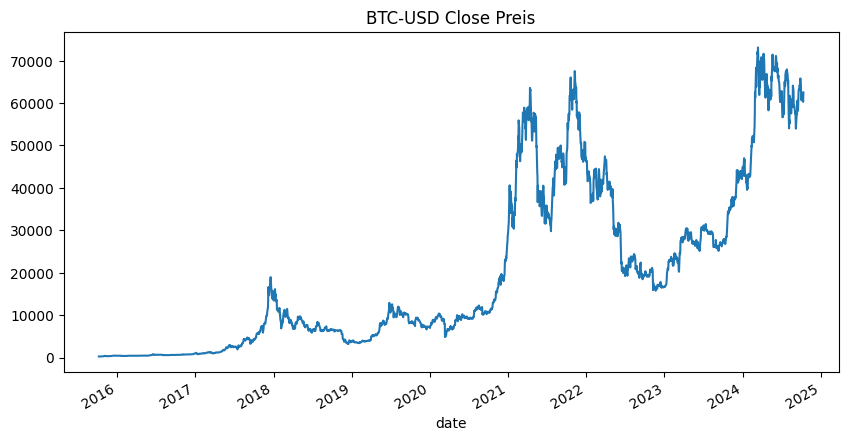

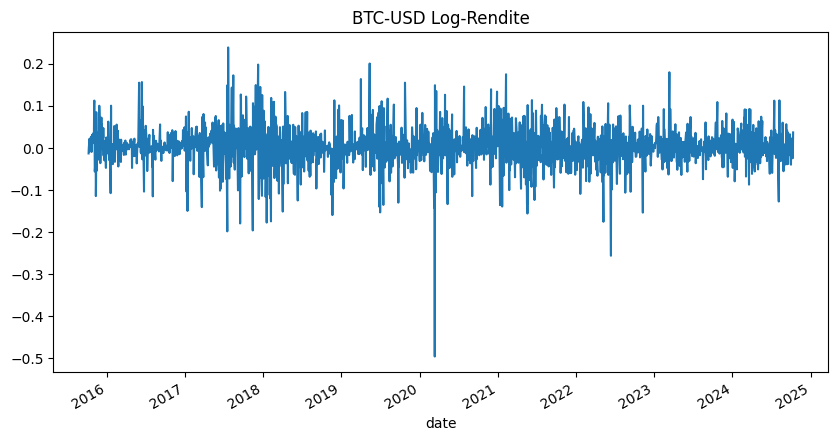

In [6]:
df_clean = load_and_info(DATA_DIR / "clean" / "features_v1.parquet")
display(df_clean.head(1200), df_clean.tail())
# Spaltenliste
print(df_clean.columns.tolist()[:15], "...")

# Ein Asset über Zeitraum herausfiltern
asset = "BTC-USD"
date_range = slice("2015-10-08", "2024-10-13")
df_clean_asset = df_clean.xs(asset, level="asset").loc[date_range]
display(df_clean_asset.head(252))

# Plot Close Preis
df_clean_asset["adj_close"].plot(title=f"{asset} Close Preis", figsize=(10,5))
plt.show()

# Plot Log-Renditen
df_clean_asset["daily_return_log"].plot(title=f"{asset} Log-Rendite", figsize=(10,5))
plt.show()



In [15]:
df_rf = load_and_info(DATA_DIR / "clean" / "riskfree.parquet")
display(df_rf.head(1000), df_rf.tail())


--- riskfree.parquet ---
Shape: (2839, 3)
Columns: 3


Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)



--- portfolio_snapshots.parquet ---
Shape: (7542, 9)
Columns: 9


Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)



--- trade_events.parquet ---
Shape: (61, 11)
Columns: 11


Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)



--- rewards_log.parquet ---
Shape: (30, 18)
Columns: 18


Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


<Axes: title={'center': 'Rewards pro Round'}, xlabel='round'>

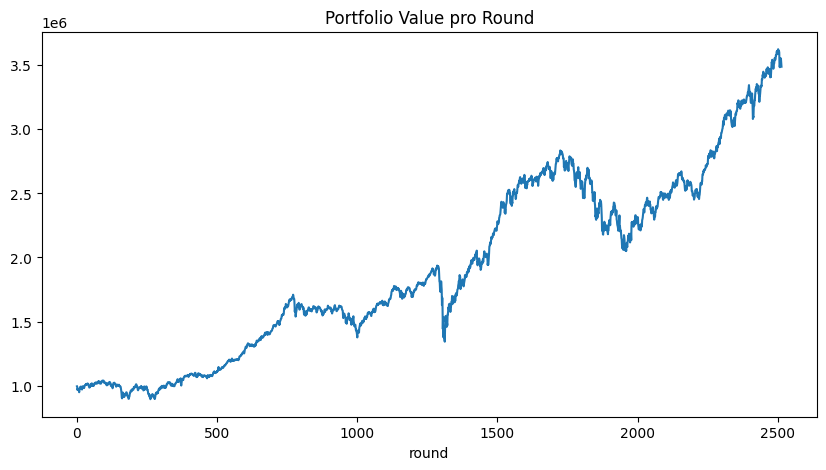

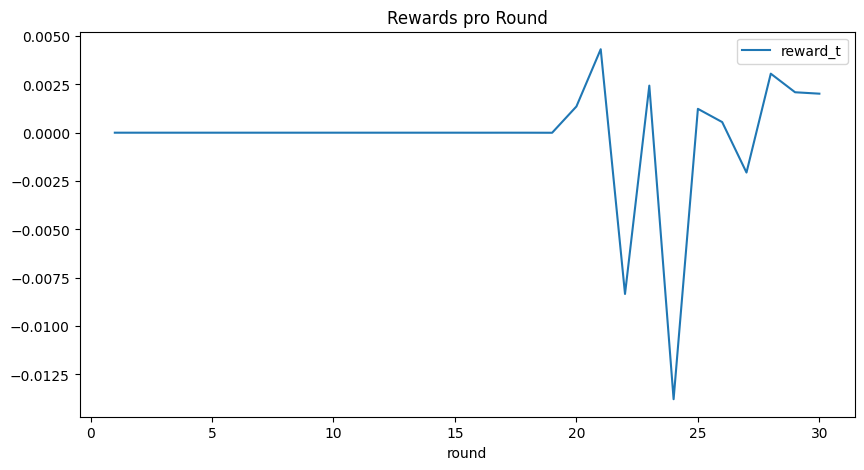

In [44]:
acc_demo = DATA_DIR / "accounting_demo"

df_snap = load_and_info(acc_demo / "portfolio_snapshots.parquet")
display(df_snap.head(820), df_snap.tail(100))

df_trades = load_and_info(acc_demo / "trade_events.parquet")
display(df_trades.head(484), df_trades.tail(10))

df_rewards = load_and_info(acc_demo / "rewards_log.parquet")
display(df_rewards.head(20), df_rewards.tail(20))

# Plot Portfolio Value Verlauf
df_snap.groupby("round")["portfolio_value_t"].mean().plot(
    title="Portfolio Value pro Round", figsize=(10,5))
#plt.show()

# Plot Rewards Verlauf
df_rewards.plot(x="round", y="reward_t", title="Rewards pro Round", figsize=(10,5))
#plt.show()

In [25]:
df_2015_01_02 = df_clean.xs("2015-01-02", level="date")
df_2015_01_02.loc["SPY"].filter(like="moving_average")

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [27]:
df_state = load_and_info(DATA_DIR / "states" / "states_demo" / "state_scalars.parquet")
display(df_state.head(128), df_state.tail())


--- state_scalars.parquet ---
Shape: (2, 4)
Columns: 4


Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [7]:
df_state = load_and_info(DATA_DIR / "clean" / "cpcv" / "years" / "2016" / "2016_features.parquet")
display(df_state.head(20), df_state.tail(10))


--- 2016_features.parquet ---
Shape: (2016, 62)
Columns: 62


Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [26]:
df_state = load_and_info(DATA_DIR / "accounting" / "runs" / "smoke_cpcv_ppo" / "ppo_log_state0_cpcv_20250921_193127" / "fold_01" / "test" /  "seg_01"/ "portfolio_snapshots.parquet")
display(df_state.head(200), df_state.tail(10))


--- portfolio_snapshots.parquet ---
Shape: (2016, 9)
Columns: 9


Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [14]:
df_state = load_and_info(DATA_DIR / "accounting" / "runs" / "smoke_cpcv_ppo" / "ppo_log_state0_cpcv_20250921_193127" / "fold_01" / "test" /  "seg_01"/ "trade_events.parquet")
display(df_state.head(20), df_state.tail(10))


--- trade_events.parquet ---
Shape: (83, 11)
Columns: 11


Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [23]:
df_state = load_and_info(DATA_DIR / "accounting" / "runs" / "smoke_cpcv_ppo" / "ppo_log_state0_cpcv_20250921_193127" / "fold_05" / "test" /  "seg_02"/ "rewards.parquet")
display(df_state.head(20), df_state.tail(10))


--- rewards.parquet ---
Shape: (252, 15)
Columns: 15


Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)
